### Полиномизация в линейной регрессии — это способ научить линейную модель улавливать нелинейные зависимости, не меняя саму природу модели.

### Степень полинома — ключевой параметр. Высокая степень -> риск переобучения.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df_Advertising = pd.read_csv(r"Advertising.csv")

X = df_Advertising.drop('sales', axis=1)
y = df_Advertising['sales']

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [13]:
polynom_converter = PolynomialFeatures(degree = 3, include_bias=False)
X_converter = polynom_converter.fit_transform(X)

model = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X_converter, y, test_size=0.33, random_state=101)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
mean = df_Advertising['sales'].mean()
print(f"Процент ошибок равен {RMSE / mean * 100:.2f}")
print(RMSE)

Процент ошибок равен 3.98
0.5577254823386943


# Посмотрим на график остатков, сделаем выводы от модели

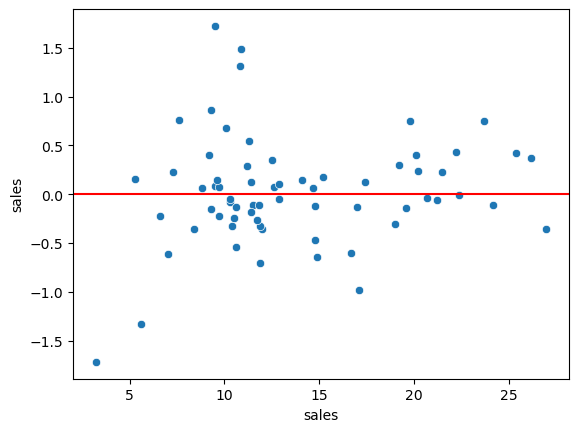

In [14]:
residuals = y_test - y_pred
sns.scatterplot(x = y_test, y = residuals)
plt.axhline(y=0, c='r')

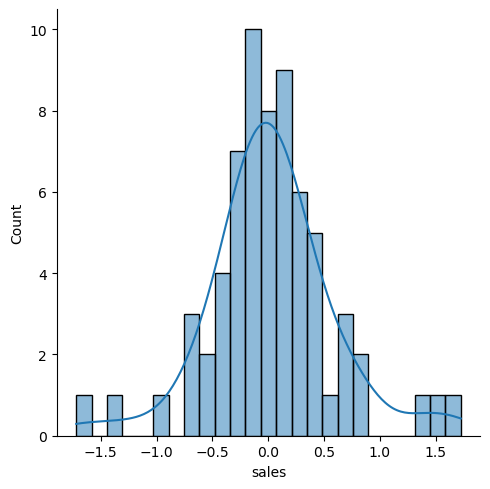

In [15]:
sns.displot(residuals, bins=25, kde=True)

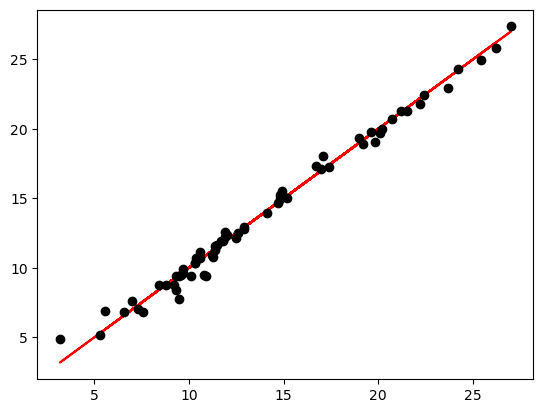

In [16]:
plt.plot(y_test, y_test, c="r")
plt.plot(y_test, y_pred, "ko")

---
---
## Выбираем модель

### Подбор параметров

Нравится ли нам точность модели? Может быть, более высокая степень полинома ещё больше улучшит результаты? Но не будет ли так, что большие значения степени будут слишком большими? Я посмотрю на дальнейшие степени полиномов, каждый раз смотря на ошибки предсказания. В итоге мы поймем, переобучили ли  модель? (overfitting).

С помощью цикла for сделаем следующее:

1. Создадим полиномиальные данные некоторой степени для данных X
2. Разобъём полиномиальные данные для обучающий и тестовый наборы данных
3. Выполним обучение модели на обучающем наборе данных
4. Посчитаем метрики на обучающем *и* тестовом наборе данных
5. Нанесём эти данные на график, чтобы увидеть момент переобучения модели

In [20]:
from tqdm import tqdm

# Ошибка на обучающем наборе для той или иной степени полинома
train_rmse_errors = []
# Ошибка на тестовом наборе для той или иной степени полинома
test_rmse_errors = []

for d in tqdm(range(1,10)):
    
    # Создаём полиномиальные данные для степени "d"
    polynomial_converter = PolynomialFeatures(degree=d,include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)
    
    # Разбиваем эти новые полиномиальные данные на обучающий и тестовый наборы данных
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    # Обучаем модель на этом новом наборе полиномиальных данных
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train,y_train)
    
    # Выполняем предсказание и на обучающем, и на тестовом наборе данных
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Вычисляем ошибки
    
    # Ошибки на обучающем наборе данных
    train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))
    
    # Ошибки на тестовом наборе данных
    test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))

    # Добавляем ошибки в список для последующего нанесения на график
       
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 75.05it/s]


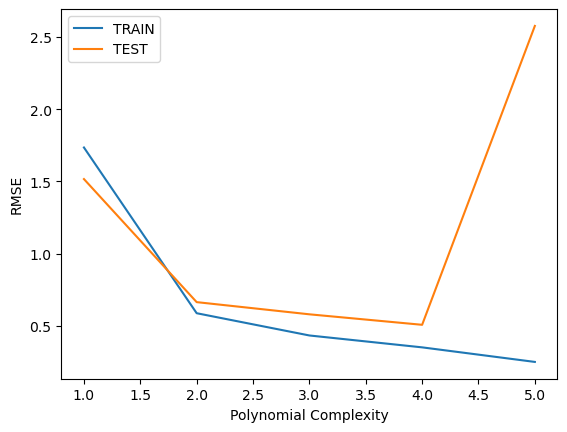

In [18]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

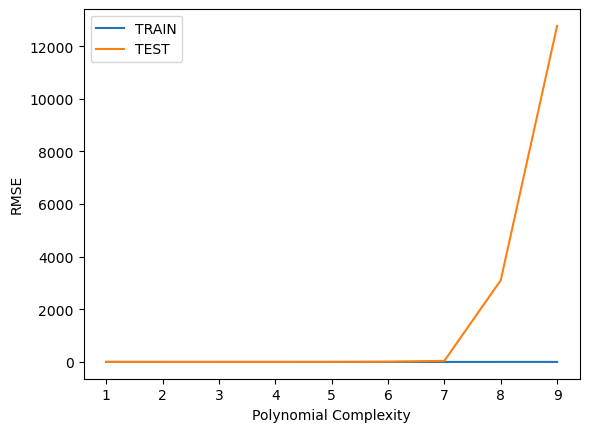

In [21]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

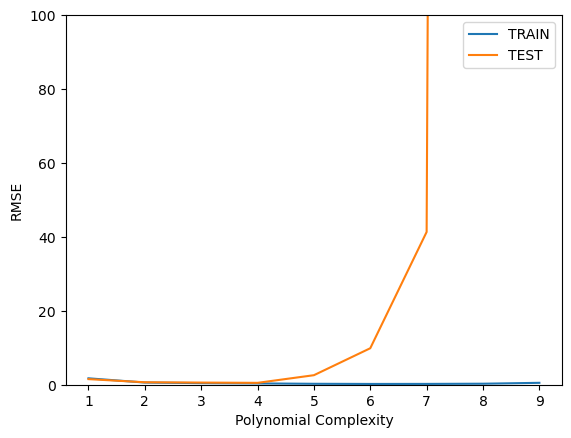

In [22]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.ylim(0,100)
plt.legend()

## Финальный выбор модели

Здесь нам нужно сохранить 2 вещи - объект создания полиномиальных признаков, а также саму модель. Дальнейшие шаги будут следующие:

1. Выбираем финальные значения параметров на основе тестовых метрик
2. Выполняем повторное обучение на всех данных
3. Сохраняем объект Polynomial Converter
4. Сохраняем модель

In [23]:
# На нашем графике видно, что мы могли бы выбрать и значение degree=4, однако
# безопаснее взять чуть меньшую степень сложности
final_poly_converter = PolynomialFeatures(degree=3,include_bias=False)

In [24]:
final_model = LinearRegression()

In [25]:
final_model.fit(final_poly_converter.fit_transform(X),y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
from joblib import dump, load

In [27]:
dump(final_model, 'sales_poly_model.joblib') 

['sales_poly_model.joblib']

In [28]:
dump(final_poly_converter,'poly_converter.joblib')

['poly_converter.joblib']